In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from IPython.display import display, Markdown

mpl.rcParams['font.size'] = 16

In [5]:
def read_file(filename, total_comps):
    with open(filename) as f:
        time, ops = [], []
        for line in f:
            line =  line.rstrip().lstrip()
            if not line:
                continue

            temp = line.split()
            time.append(float(temp[4]))
            if len(temp) > 5:
                ops.append((int(temp[5])/total_comps)*100)

    return time, ops

def read_file_with_smiles(filename):
    with open(filename) as f:
        data = []
        for line in f:
            line =  line.rstrip().lstrip()
            if not line:
                continue

            temp = line.split()
            data.append(float(temp[5]))

    return data

def plot_ops_voilin(ops_data):
    fig = plt.figure(figsize=(10, 5))
    ax1 = fig.add_subplot(111)
    ax1.voilinplot(ops_data.values(), bins=range(0, int(np.max(data))))
    #ax1.set_xlabel('time [ms]')
    #ax1.set_xlim(0, 90)
    #ax1.set_ylabel('Queries #')

    fig.savefig(f'sim-ops-vs-cutoff.png', dpi=300)
    plt.show()

def percentiles(data):
    return np.percentile(data, 99), np.percentile(data, 90), np.percentile(data, 75), np.percentile(data, 50), np.percentile(data, 25)

def print_times_percentile_table(data, table_name):
    md_output=f'''
## {table_name}
**Total time**: {np.sum(data):.3f} ms

**Average time**: {np.mean(data):.3f} ms

| Queries resolved (percentile)  | Time (ms) |
| -------------------------------| -----------|
| 99  | {np.percentile(data, 99):.3f} |
| 90  | {np.percentile(data, 90):.3f} |
| 75  | {np.percentile(data, 75):.3f} |
| 50  | {np.percentile(data, 50):.3f} |
| 25  | {np.percentile(data, 25):.3f} |
    '''
    display(Markdown(md_output))

In [6]:
times_percentile_data = {}
times_data = {}
ops_data = {}
cutoffs =  {"10": 0.1, "11": 0.11, "12": 0.12, "13": 0.13, "14": 0.14, "15": 0.15, "16": 0.16,
           "17": 0.17, "18": 0.18, "19": 0.19, "20": 0.20, "21": 0.21, "22": 0.22, "23": 0.23, "24": 0.24, "25": 0.25}

times, ops = read_file(f"../fpsim2_benchmark/benchmarking.log", 2474590.0)
times_percentile_data["FPSim2"] = percentiles(times)
for key, value in cutoffs.items():
    times, ops = read_file(f"benchmark_{key}.log", 2474590.0)
    times_percentile_data[str(value)] = percentiles(times)
    ops_data[str(value)] = ops
    times_data[str(value)] = times

In [7]:
header = ["cut-off", "99%", "90%", "75%", "50%", "25%"]
with open("benchmark_b2048.csv", "w") as fin:
    fin.write(",".join(header))
    fin.write("\n")
    for key, value in times_percentile_data.items():
        fin.write(f"{key},")
        fin.write(",".join(map(lambda x: f'{x:.2f}',value)))
        fin.write("\n")

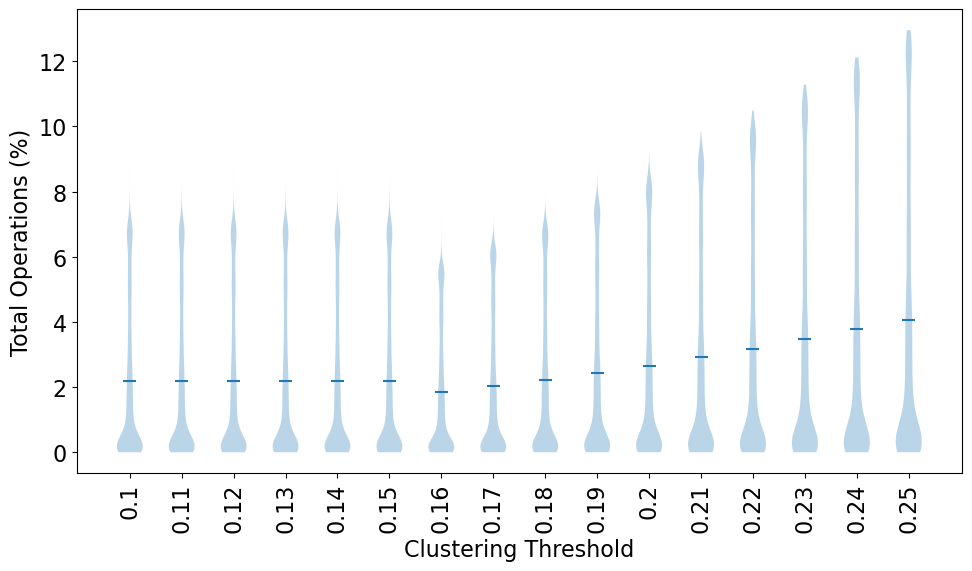

In [5]:
def plot_ops_violin(ops_data):
    fig = plt.figure(figsize=(10, 6))
    ax1 = fig.add_subplot(111)
    ax1.violinplot(ops_data.values(), showextrema=False, showmeans=True)
    ax1.set_xticks(range(1, 17), ops_data.keys(), rotation="vertical")
    #ax1.set_yscale("log")
    ax1.set_xlabel('Clustering Threshold')
    #ax1.set_xlim(0, 90)
    ax1.set_ylabel('Total Operations (%)')
    
    fig.tight_layout()
    fig.savefig(f'sim-ops-vs-cutoff.png', dpi=300)
    
    plt.show()

#print(ops_data.values())
plot_ops_violin(ops_data)

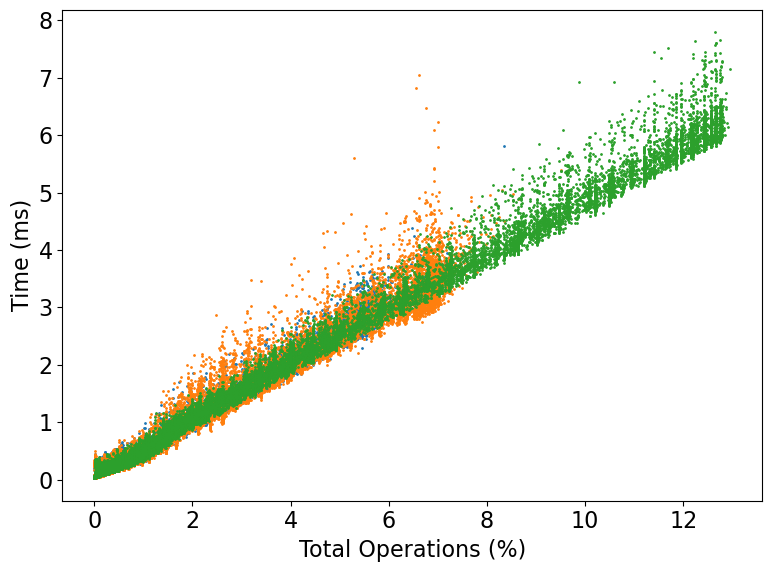

In [6]:
def plot_time_vs_ops(times_data, ops_data):
    fig = plt.figure(figsize=(8, 6))
    ax1 = fig.add_subplot(111)
    ax1.scatter(ops_data["0.16"], times_data["0.16"], s=1)
    ax1.scatter(ops_data["0.1"], times_data["0.1"], s=1)
    ax1.scatter(ops_data["0.25"], times_data["0.25"], s=1)
    #ax1.set_yscale("log")
    ax1.set_ylabel('Time (ms)')
    #ax1.set_xlim(0, 90)
    ax1.set_xlabel('Total Operations (%)')
    
    fig.tight_layout()
    fig.savefig(f'time_vs_ops.png', dpi=300)
    
    plt.show()

plot_time_vs_ops(times_data, ops_data)